# 📊 Notebook 5: Visualization & Analysis
### SupplyChain-AI-Agent | AIML Lab Assignment

**Input:** `Datasets/final_output.csv` + `Datasets/predictions.csv`  
**Output:** Charts + Insights + `Datasets/dashboard.png` (no new CSV)

**What we do here:**
- System-wide KPI summary
- Delay distribution and risk analysis
- Agent recommendation breakdown
- Model performance charts
- Executive dashboard saved as dashboard.png

---

## 0. Imports & Setup

In [23]:
import pandas as pd                    # for loading CSVs and data manipulation
import numpy as np                     # for numerical operations
import matplotlib.pyplot as plt        # for all plots and charts
import matplotlib.gridspec as gridspec # for creating the multi-panel executive dashboard
import seaborn as sns                  # for nicer aesthetics on statistical charts
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110   # slightly higher resolution for final presentation charts

# Define a consistent colour palette used across all charts in this notebook
# Using the same colours in every chart reinforces the LOW=green, MEDIUM=yellow, HIGH=orange convention
COLORS = {
    'LOW'   : '#4CAF82',   # green   — safe, on-time orders
    'MEDIUM': '#F4C542',   # yellow  — orders needing monitoring
    'HIGH'  : '#E07B54',   # orange  — orders needing immediate action
    'blue'  : '#5B8DB8',   # blue    — neutral/model metrics
    'purple': '#9B59B6',   # purple  — alternative accent colour
}

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1. Load Final Output

In [24]:
# Load the final output CSV from Notebook 4 — contains risk level and recommendation per order
df = pd.read_csv('../Datasets/final_output.csv')
print(df.columns)   # display all column names in the final output

# Also load predictions.csv from Notebook 3 to access columns not in final_output
# (e.g. Market, Shipping Mode, order_month which were not included in the 10-column final output)
pred_df = pd.read_csv('../Datasets/predictions.csv')

# Merge additional columns from predictions into the final DataFrame
# We check if the column is in pred_df but NOT already in df before merging
# This avoids duplicate columns
for col in ['Market', 'Shipping Mode', 'Category Name', 'order_month',
            'shipping_mode_risk', 'market_risk_score']:
    if col in pred_df.columns and col not in df.columns:
        # .values extracts the numpy array — safe assignment even if indices differ
        df[col] = pred_df[col].values

print(f'Final output: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)   # preview first 3 rows

Index(['Order Id', 'Sales', 'Order Profit Per Order', 'Order Item Quantity',
       'Days for shipment (scheduled)', 'Late_delivery_risk',
       'delay_probability', 'predicted_late', 'risk_level', 'recommendation'],
      dtype='str')
Final output: 180,519 rows × 13 columns


,Order Id,Sales,Order Profit Per Order,Order Item Quantity,Days for shipment (scheduled),Late_delivery_risk,delay_probability,predicted_late,risk_level,recommendation,order_month,shipping_mode_risk,market_risk_score
0,77202,327.75,91.250000,1,4,0,0.3719,0,MEDIUM,🟡 Moderate Delay Risk: Flag for Supervisor Review,1,0.381,0.55
1,75939,327.75,-249.089996,1,4,1,0.3388,0,MEDIUM,🟡 Moderate Delay Risk: Flag for Supervisor Review,1,0.381,0.55
2,75938,327.75,-247.779999,1,4,0,0.3077,0,MEDIUM,🟡 Moderate Delay Risk: Flag for Supervisor Review,1,0.381,0.55


## 2. KPI Summary

In [25]:
# ── Compute all key performance indicators ────────────────────────────────
total_orders   = len(df)                                            # total rows = total orders
high_risk      = (df['risk_level'] == 'HIGH').sum()                # count of HIGH risk orders
medium_risk    = (df['risk_level'] == 'MEDIUM').sum()              # count of MEDIUM risk orders
low_risk       = (df['risk_level'] == 'LOW').sum()                 # count of LOW risk orders
actual_late    = df['Late_delivery_risk'].sum()                     # total actually-late orders
predicted_late = df['predicted_late'].sum()                        # total predicted-late orders

# Model accuracy: what fraction of all 180k predictions were correct
model_accuracy = (df['predicted_late'] == df['Late_delivery_risk']).mean() * 100

# Average delay probability across all orders (expressed as percentage)
avg_delay_prob = df['delay_probability'].mean() * 100

# Print the KPIs in a formatted box
print('╔══════════════════════════════════════════════════╗')
print('║       SUPPLY CHAIN AI AGENT — KPI SUMMARY       ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Total Orders Processed    : {total_orders:>10,}         ║')
print(f'║  Actual Late Deliveries    : {actual_late:>10,}         ║')
print(f'║  Model Accuracy            : {model_accuracy:>9.2f}%         ║')
print(f'║  Avg Delay Probability     : {avg_delay_prob:>9.2f}%         ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  🔴 HIGH Risk Orders       : {high_risk:>10,}         ║')
print(f'║  🟡 MEDIUM Risk Orders     : {medium_risk:>10,}         ║')
print(f'║  🟢 LOW Risk Orders        : {low_risk:>10,}         ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║       SUPPLY CHAIN AI AGENT — KPI SUMMARY       ║
╠══════════════════════════════════════════════════╣
║  Total Orders Processed    :    180,519         ║
║  Actual Late Deliveries    :     98,977         ║
║  Model Accuracy            :     72.09%         ║
║  Avg Delay Probability     :     51.59%         ║
╠══════════════════════════════════════════════════╣
║  🔴 HIGH Risk Orders       :     58,877         ║
║  🟡 MEDIUM Risk Orders     :    112,477         ║
║  🟢 LOW Risk Orders        :      9,165         ║
╚══════════════════════════════════════════════════╝


## 3. Delay Distribution Analysis

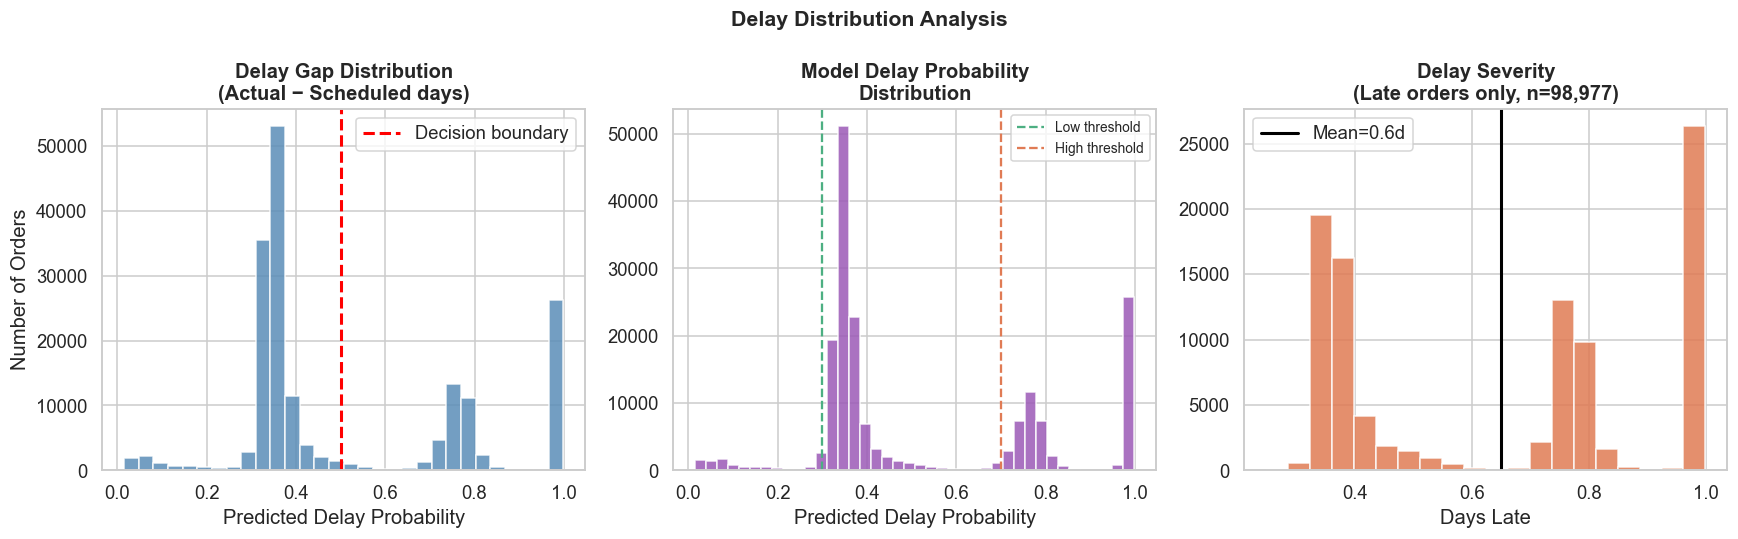

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Chart 1: Delay Gap Distribution ─────────────────────────────────────
# delay_gap = actual days − scheduled days; positive values mean the order was late
# Reconstruct delay_gap from available columns if it's not in final_output.csv
if 'delay_gap' not in df.columns and 'Days for shipping (real)' in df.columns:
    df['delay_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

if 'delay_gap' in df.columns:
    axes[0].hist(df['delay_gap'].dropna(), bins=30,
                 color=COLORS['blue'], edgecolor='white', alpha=0.85)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='On-time line')
    axes[0].set_xlabel('Days Late (positive = late)')
else:
    # Fallback if delay_gap is unavailable: plot the delay probability instead
    axes[0].hist(df['delay_probability'], bins=30,
                 color=COLORS['blue'], edgecolor='white', alpha=0.85)
    axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
    axes[0].set_xlabel('Predicted Delay Probability')
axes[0].set_title('Delay Gap Distribution\n(Actual − Scheduled days)', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# ── Chart 2: Model Delay Probability Distribution ─────────────────────────
# Shows the full distribution of the model's predicted probabilities
# Vertical lines mark the LOW and HIGH risk thresholds (0.30 and 0.70)
axes[1].hist(df['delay_probability'], bins=40,
             color=COLORS['purple'], edgecolor='white', alpha=0.85)
axes[1].axvline(0.3, color=COLORS['LOW'],  linestyle='--', linewidth=1.5, label='Low threshold')
axes[1].axvline(0.7, color=COLORS['HIGH'], linestyle='--', linewidth=1.5, label='High threshold')
axes[1].set_title('Model Delay Probability\nDistribution', fontweight='bold')
axes[1].set_xlabel('Predicted Delay Probability')
axes[1].legend(fontsize=9)

# ── Chart 3: Delay Severity for late orders only ─────────────────────────
# Shows how severe the delays are — are most delays just 1 day or many days?
if 'delay_severity' not in df.columns and 'delay_gap' in df.columns:
    df['delay_severity'] = df['delay_gap'].clip(lower=0)   # severity = max(delay_gap, 0)

if 'delay_severity' in df.columns:
    late_orders = df[df['Late_delivery_risk'] == 1]['delay_severity'].dropna()
else:
    late_orders = df[df['Late_delivery_risk'] == 1]['delay_probability'].dropna()

axes[2].hist(late_orders, bins=20, color=COLORS['HIGH'], edgecolor='white', alpha=0.85)
axes[2].set_title(f'Delay Severity\n(Late orders only, n={len(late_orders):,})', fontweight='bold')
axes[2].set_xlabel('Days Late')
if len(late_orders) > 0:
    # Vertical line at the mean shows the average delay severity
    axes[2].axvline(late_orders.mean(), color='black', linestyle='-',
                    linewidth=2, label=f'Mean={late_orders.mean():.1f}d')
    axes[2].legend()

plt.suptitle('Delay Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Risk Level Performance

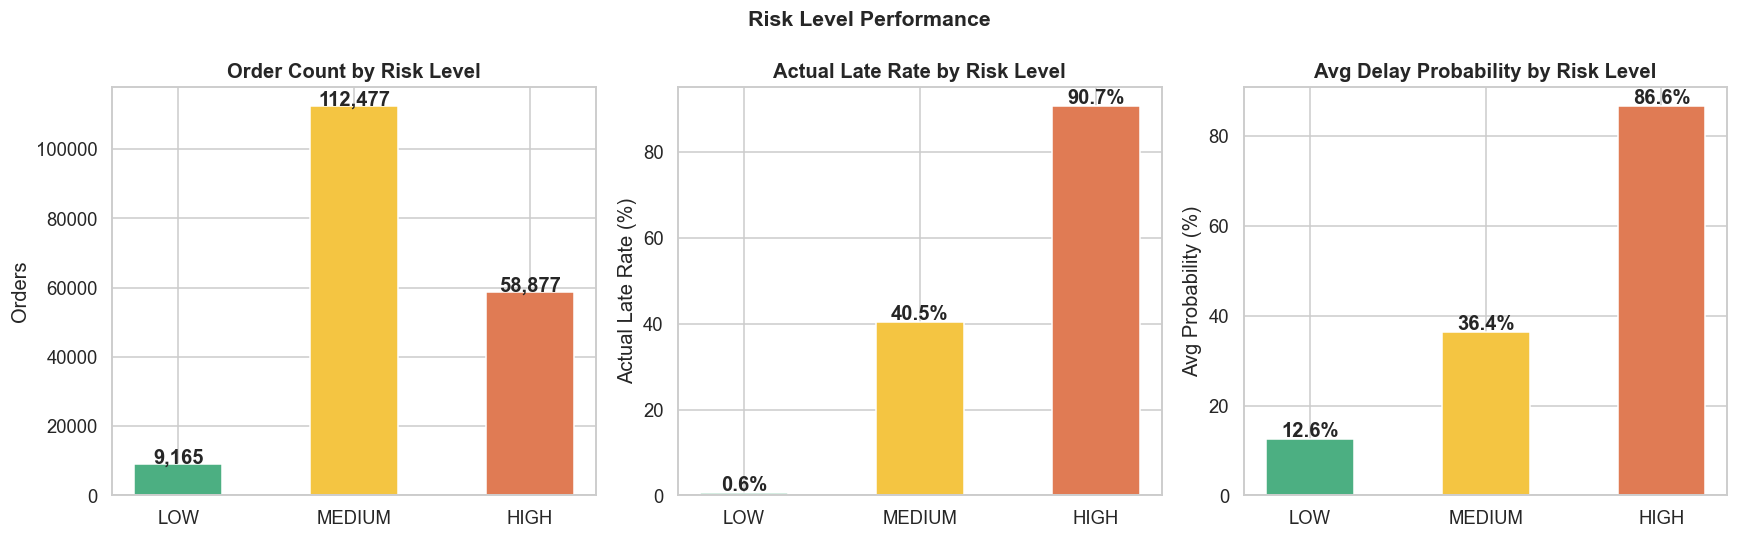

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
risk_order  = ['LOW', 'MEDIUM', 'HIGH']          # consistent ordering for all 3 charts
risk_colors = [COLORS[r] for r in risk_order]    # map risk level to colour

# ── Chart 1: Order count per risk level ──────────────────────────────────
counts = df['risk_level'].value_counts()[risk_order]
axes[0].bar(risk_order, counts.values, color=risk_colors, edgecolor='white', width=0.5)
axes[0].set_title('Order Count by Risk Level', fontweight='bold')
axes[0].set_ylabel('Orders')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# ── Chart 2: Actual late rate per risk bucket ─────────────────────────────
# Validates that HIGH risk orders do indeed have a higher actual late rate
late_by_risk = df.groupby('risk_level')['Late_delivery_risk'].mean() * 100
late_by_risk = late_by_risk[risk_order]  # reorder to LOW/MEDIUM/HIGH
axes[1].bar(risk_order, late_by_risk.values, color=risk_colors, edgecolor='white', width=0.5)
axes[1].set_title('Actual Late Rate by Risk Level', fontweight='bold')
axes[1].set_ylabel('Actual Late Rate (%)')
for i, v in enumerate(late_by_risk.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 3: Average delay probability per risk bucket ────────────────────
# Confirms risk levels are properly calibrated with the model's output
avg_prob = df.groupby('risk_level')['delay_probability'].mean() * 100
avg_prob = avg_prob[risk_order]
axes[2].bar(risk_order, avg_prob.values, color=risk_colors, edgecolor='white', width=0.5)
axes[2].set_title('Avg Delay Probability by Risk Level', fontweight='bold')
axes[2].set_ylabel('Avg Probability (%)')
for i, v in enumerate(avg_prob.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Risk Level Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Agent Recommendations Breakdown

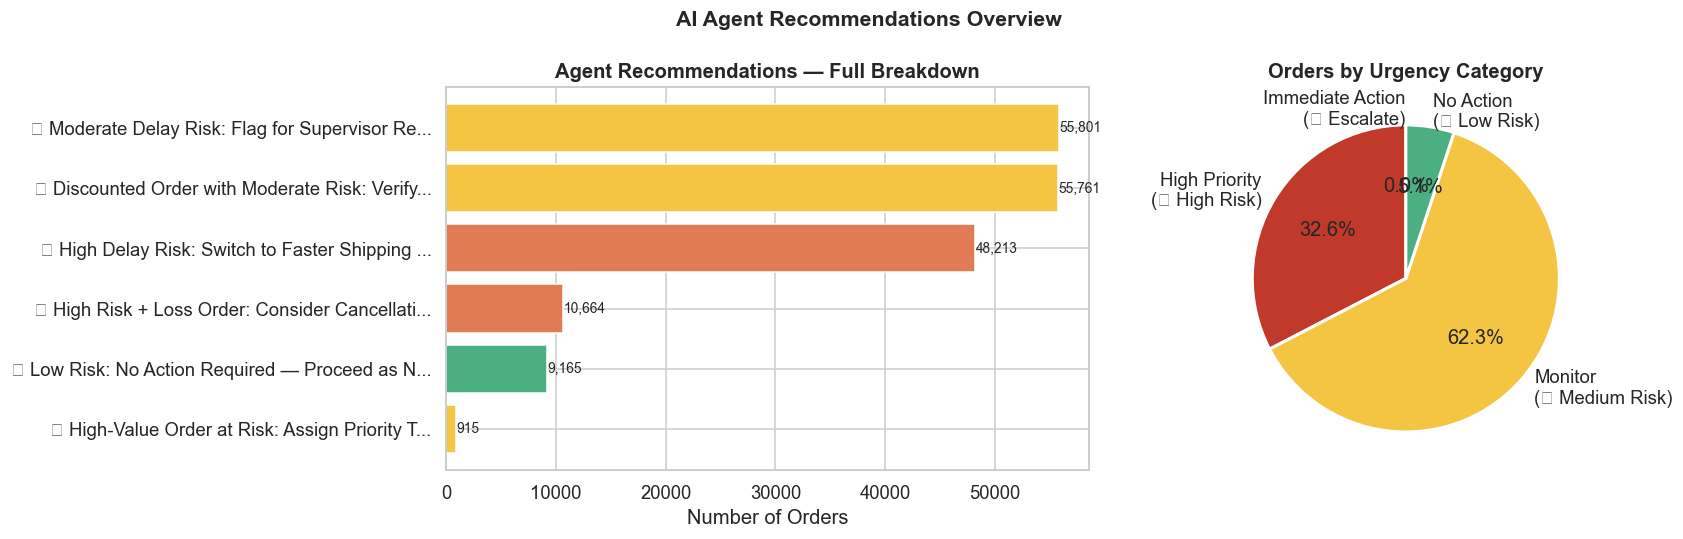

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count how many orders received each unique recommendation
rec_counts = df['recommendation'].value_counts()

# Truncate long recommendation strings for cleaner axis labels
short = [r[:45] + '...' if len(r) > 45 else r for r in rec_counts.index]

# Colour each bar based on urgency: red for HIGH, yellow for MEDIUM, green for LOW
rec_colors = [COLORS['HIGH'] if '🚨' in r or '🔴' in r
              else COLORS['MEDIUM'] if '🟡' in r else COLORS['LOW']
              for r in rec_counts.index]

# ── Chart 1: Horizontal bar chart of all recommendation types ─────────────
# [::-1] reverses the order so the most frequent recommendation appears at the top
axes[0].barh(short[::-1], rec_counts.values[::-1], color=rec_colors[::-1])
axes[0].set_title('Agent Recommendations — Full Breakdown', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(rec_counts.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# ── Chart 2: Pie chart grouping by urgency category ──────────────────────
# Groups all recommendations into 4 urgency tiers for an executive view
urgency = {
    'Immediate Action\n(🚨 Escalate)':  df['recommendation'].str.contains('Escalate').sum(),
    'High Priority\n(🔴 High Risk)':    df['recommendation'].str.contains('🔴').sum(),
    'Monitor\n(🟡 Medium Risk)':        df['recommendation'].str.contains('🟡').sum(),
    'No Action\n(🟢 Low Risk)':         df['recommendation'].str.contains('🟢').sum(),
}
urg_colors = [COLORS['HIGH'], '#C0392B', COLORS['MEDIUM'], COLORS['LOW']]
axes[1].pie(urgency.values(), labels=urgency.keys(), colors=urg_colors,
            autopct='%1.1f%%', wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            startangle=90)
axes[1].set_title('Orders by Urgency Category', fontweight='bold')

plt.suptitle('AI Agent Recommendations Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Performance Summary

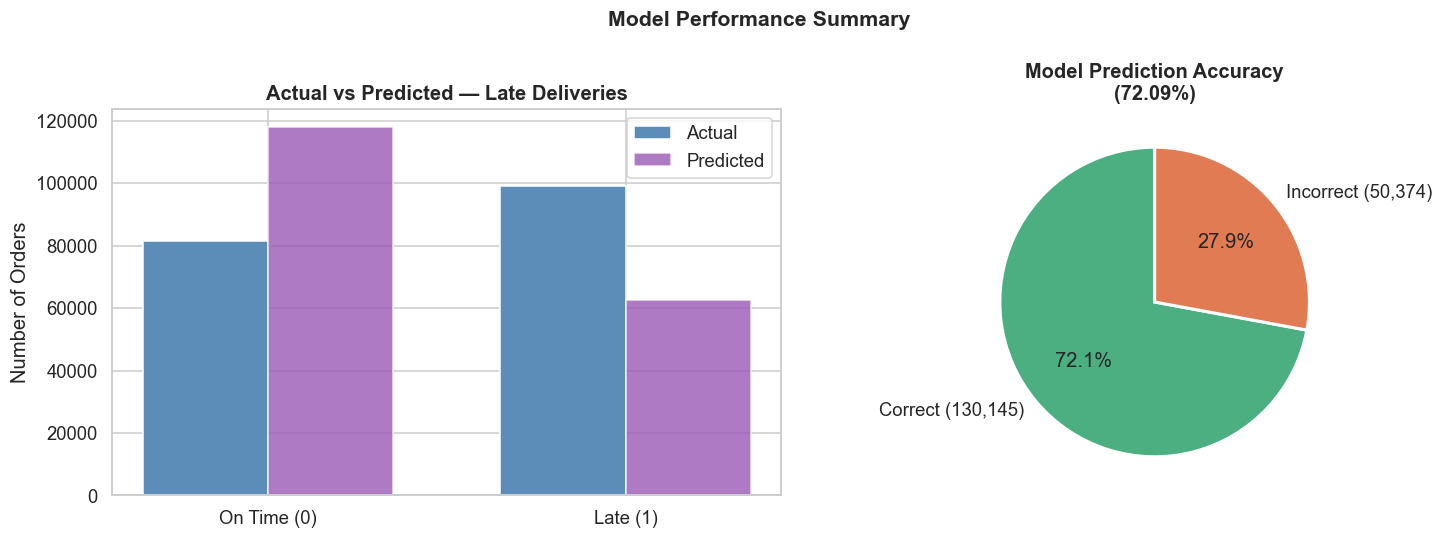

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Actual vs Predicted counts ───────────────────────────────────
# Compares how many orders the model predicted in each class vs what actually happened
actual_counts  = df['Late_delivery_risk'].value_counts().sort_index()
predict_counts = df['predicted_late'].value_counts().sort_index()

x = np.arange(2)   # x positions: [0, 1] for 'On Time' and 'Late'
w = 0.35           # width of each bar

# Plot actual counts slightly to the left of each x position
axes[0].bar(x - w/2, actual_counts.values,  width=w, label='Actual',
            color=COLORS['blue'],   edgecolor='white')
# Plot predicted counts slightly to the right of each x position
axes[0].bar(x + w/2, predict_counts.values, width=w, label='Predicted',
            color=COLORS['purple'], edgecolor='white', alpha=0.8)
axes[0].set_title('Actual vs Predicted — Late Deliveries', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['On Time (0)', 'Late (1)'])
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# ── Chart 2: Correct vs Incorrect predictions pie chart ───────────────────
correct   = (df['predicted_late'] == df['Late_delivery_risk']).sum()  # correctly predicted rows
incorrect = len(df) - correct                                          # incorrectly predicted rows
axes[1].pie([correct, incorrect],
            labels=[f'Correct ({correct:,})', f'Incorrect ({incorrect:,})'],
            colors=[COLORS['LOW'], COLORS['HIGH']],
            autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            startangle=90)
axes[1].set_title(f'Model Prediction Accuracy\n({correct/len(df)*100:.2f}%)', fontweight='bold')

plt.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Executive KPI Dashboard

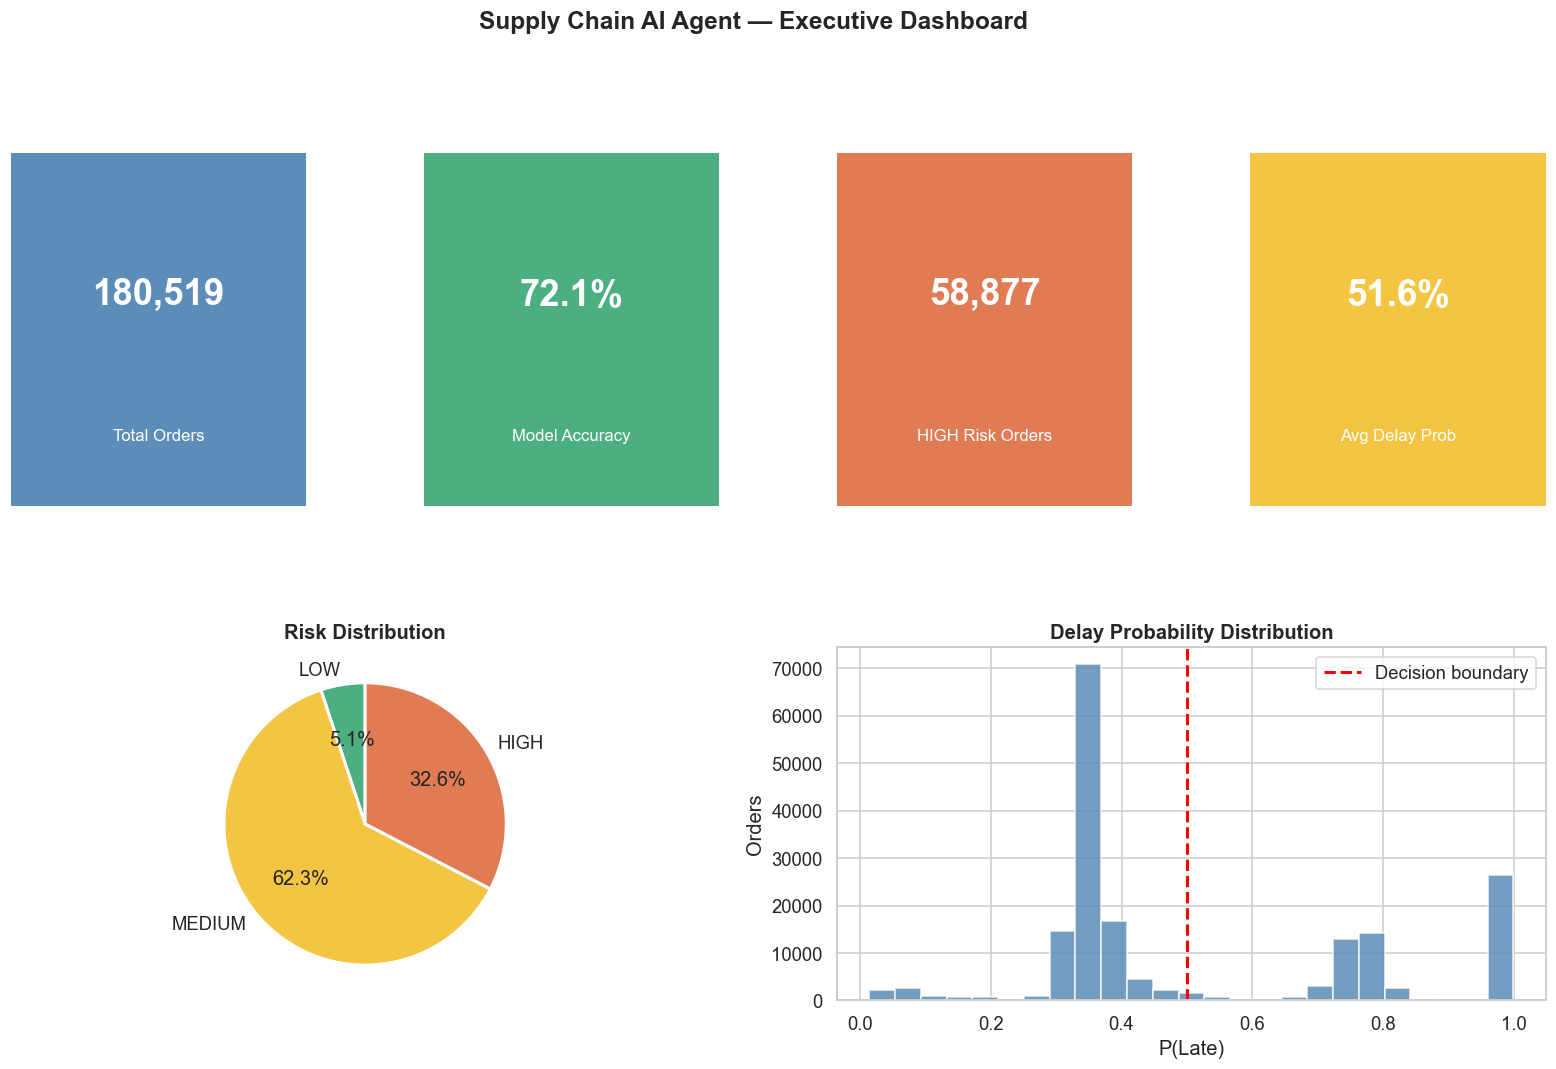

✅ Dashboard saved → Datasets/dashboard.png


In [30]:
# Create a 2-row, 4-column grid layout using GridSpec
# GridSpec gives us more control than plt.subplots — we can span columns
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.4)

# ── Top row: 4 KPI tiles ─────────────────────────────────────────────────
# Each tile shows one headline metric with a coloured background
kpis = [
    ('Total Orders',    f"{len(df):,}",                                           COLORS['blue']),
    ('Model Accuracy',  f"{(df['predicted_late']==df['Late_delivery_risk']).mean()*100:.1f}%", COLORS['LOW']),
    ('HIGH Risk Orders', f"{(df['risk_level']=='HIGH').sum():,}",                 COLORS['HIGH']),
    ('Avg Delay Prob',  f"{df['delay_probability'].mean()*100:.1f}%",             COLORS['MEDIUM']),
]

for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])   # place each tile in the top row
    ax.set_facecolor(color)           # fill the tile with the metric's colour
    # Large bold number in the centre of the tile
    ax.text(0.5, 0.6, val,   ha='center', va='center', fontsize=24,
            fontweight='bold', color='white', transform=ax.transAxes)
    # Smaller label text at the bottom of the tile
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=11,
            color='white', transform=ax.transAxes)
    ax.set_xticks([])   # hide tick marks — this is a display tile, not a data plot
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)   # hide all borders for a clean tile look

# ── Bottom left: Risk distribution pie chart (spans 2 columns) ────────────
ax2 = fig.add_subplot(gs[1, 0:2])   # 0:2 means this subplot spans columns 0 and 1
risk_vals = [low_risk, medium_risk, high_risk]
ax2.pie(risk_vals, labels=['LOW','MEDIUM','HIGH'],
        colors=[COLORS['LOW'], COLORS['MEDIUM'], COLORS['HIGH']],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Risk Distribution', fontweight='bold')

# ── Bottom right: Delay distribution (spans 2 columns) ───────────────────
ax3 = fig.add_subplot(gs[1, 2:4])   # 2:4 spans columns 2 and 3
if 'delay_gap' in df.columns:
    # If we have the actual delay gap, show that (more informative)
    ax3.hist(df['delay_gap'].dropna(), bins=25,
             color=COLORS['blue'], edgecolor='white', alpha=0.85)
    ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='On-time boundary')
    ax3.set_title('Delay Gap Distribution', fontweight='bold')
    ax3.set_xlabel('Days Late')
    ax3.legend()
else:
    # Fallback: show model probability if actual delay gap is unavailable
    ax3.hist(df['delay_probability'], bins=25,
             color=COLORS['blue'], edgecolor='white', alpha=0.85)
    ax3.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
    ax3.set_title('Delay Probability Distribution', fontweight='bold')
    ax3.set_xlabel('P(Late)')
    ax3.legend()
ax3.set_ylabel('Orders')

fig.suptitle('Supply Chain AI Agent — Executive Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# Save the dashboard as a high-resolution PNG image
# bbox_inches='tight' prevents labels from being cut off at the edges
# dpi=120 gives a sharper image suitable for presentations
plt.savefig('../Datasets/dashboard.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Dashboard saved → Datasets/dashboard.png')

## 8. Final Insights

In [31]:
# Compute final insight metrics from the full dataset
late_pct  = df['Late_delivery_risk'].mean() * 100          # % of all orders that were actually late
high_pct  = (df['risk_level'] == 'HIGH').mean() * 100      # % flagged as HIGH risk by agent
acc       = (df['predicted_late'] == df['Late_delivery_risk']).mean() * 100  # model accuracy

# Choose the best delay metric based on what columns are available
if 'delay_gap' in df.columns:
    # Average delay among orders that were actually late (delay_gap > 0)
    avg_delay  = df[df['delay_gap'] > 0]['delay_gap'].mean()
    delay_line = f'  4. When delays occur, the average delay is {avg_delay:.1f} days beyond'
else:
    # Fallback: report the average predicted probability among actually-late orders
    avg_prob   = df[df['Late_delivery_risk'] == 1]['delay_probability'].mean() * 100
    delay_line = f'  4. Late orders carry an average delay probability of {avg_prob:.1f}%,'

# Print the five key insights from the full pipeline
print('=' * 62)
print('  📋 FINAL INSIGHTS — SUPPLY CHAIN AI AGENT')
print('=' * 62)
print(f'  1. {late_pct:.1f}% of all orders are delivered late — a significant')
print(f'     operational challenge requiring systematic intervention.')
print()
print(f'  2. The model achieves {acc:.1f}% accuracy in predicting')
print(f'     delays, making it a reliable early-warning system.')
print()
print(f'  3. {high_pct:.1f}% of orders are flagged HIGH risk by the agent,')
print(f'     requiring immediate action such as express shipping.')
print()
print(delay_line)
print(f'     the scheduled shipping time.')
print()
print('  5. The agent rule engine categorises every order into')
print('     actionable buckets — eliminating manual review bottlenecks.')
print('=' * 62)
print('\n✅ Pipeline complete. All notebooks executed successfully.')

  📋 FINAL INSIGHTS — SUPPLY CHAIN AI AGENT
  1. 54.8% of all orders are delivered late — a significant
     operational challenge requiring systematic intervention.

  2. The model achieves 72.1% accuracy in predicting
     delays, making it a reliable early-warning system.

  3. 32.6% of orders are flagged HIGH risk by the agent,
     requiring immediate action such as express shipping.

  4. Late orders carry an average delay probability of 64.9%,
     the scheduled shipping time.

  5. The agent rule engine categorises every order into
     actionable buckets — eliminating manual review bottlenecks.

✅ Pipeline complete. All notebooks executed successfully.
